# Qwen2-VL Experiment

## Goal
Load and test Qwen2-VL as an independent visual evidence source.

## Why?
AllergyGuard should not depend on a single vision model.

Florence-2 provides one visual interpretation.
Qwen2-VL provides an independent visual interpretation.

## Research idea

Florence-2 + Qwen2-VL
        ↓
Independent visual evidence
        ↓
Agreement / Conflict / Uncertainty

In [1]:
import sys
import torch
import transformers

print("Python:", sys.version)
print("PyTorch:", torch.__version__)
print("Transformers:", transformers.__version__)
print("Python executable:", sys.executable)

Python: 3.12.10 (tags/v3.12.10:0cc8128, Apr  8 2025, 12:21:36) [MSC v.1943 64 bit (AMD64)]
PyTorch: 2.13.0+cpu
Transformers: 4.49.0
Python executable: C:\sem5\edi\AllergyGuard\.venv\Scripts\python.exe


## Checking Qwen2-VL Support

Before installing anything, we check whether the current
Transformers version already provides Qwen2-VL support.

This prevents unnecessary package changes from breaking
our working Florence-2 environment.

In [2]:
try:
    from transformers import Qwen2VLForConditionalGeneration
    from transformers import AutoProcessor

    print("Qwen2-VL support: AVAILABLE")
    print("Qwen2VLForConditionalGeneration: OK")
    print("AutoProcessor: OK")

except ImportError as e:
    print("Qwen2-VL support: NOT AVAILABLE")
    print("Reason:", e)

Qwen2-VL support: AVAILABLE
Qwen2VLForConditionalGeneration: OK
AutoProcessor: OK


## Checking Qwen2-VL Dependencies

The Transformers library provides the Qwen2-VL model class.

Additional packages may be needed for image and vision processing.

We check them before loading the model so that we know exactly
what is missing.

In [3]:
packages = [
    "PIL",
    "torch",
    "transformers",
]

for package in packages:
    try:
        __import__(package)
        print(f"{package}: OK")
    except ImportError:
        print(f"{package}: MISSING")

PIL: OK
torch: OK
transformers: OK


In [4]:
try:
    from transformers import Qwen2VLForConditionalGeneration
    from transformers import AutoProcessor

    print("Qwen2-VL model class: OK")
    print("Qwen2-VL processor: OK")

except Exception as e:
    print("Problem:", e)

Qwen2-VL model class: OK
Qwen2-VL processor: OK


## Qwen2-VL Model Selection

Model:
Qwen/Qwen2-VL-2B-Instruct

Reason:
We are starting with a smaller instruction-tuned model
because the current development environment uses CPU inference.

Goal:
Establish a working multimodal evidence pipeline before
considering larger models.

In [6]:
MODEL_NAME = "Qwen/Qwen2-VL-2B-Instruct"

print("Qwen2-VL model:", MODEL_NAME)

Qwen2-VL model: Qwen/Qwen2-VL-2B-Instruct


In [7]:
import torch

from transformers import (
    Qwen2VLForConditionalGeneration,
    AutoProcessor
)

print("Qwen2-VL imports successful.")

Qwen2-VL imports successful.


In [8]:
device = "cuda" if torch.cuda.is_available() else "cpu"

print("Device:", device)

Device: cpu


## Loading the Qwen2-VL Processor

The processor prepares both the image and the user's question.

Flow:

Image + Question
        ↓
    Processor
        ↓
Model-ready tensors

In [9]:
MODEL_NAME = "Qwen/Qwen2-VL-2B-Instruct"

print("Loading Qwen2-VL processor...")

processor = AutoProcessor.from_pretrained(MODEL_NAME)

print("Processor loaded successfully!")

Loading Qwen2-VL processor...


preprocessor_config.json:   0%|          | 0.00/347 [00:00<?, ?B/s]

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.48, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

chat_template.json: 0.00B [00:00, ?B/s]

Processor loaded successfully!


In [10]:
print(type(processor).__name__)

Qwen2VLProcessor


## Loading the Qwen2-VL Model

The processor prepares our image and question.

The model performs the actual multimodal inference.

Flow:

Image + Question
       ↓
   Processor
       ↓
Model-ready inputs
       ↓
   Qwen2-VL
       ↓
Generated answer

In [11]:
print("Loading Qwen2-VL model...")

model = Qwen2VLForConditionalGeneration.from_pretrained(
    MODEL_NAME,
    torch_dtype=torch.float32
)

model = model.to(device)

print("Qwen2-VL model loaded successfully!")
print("Model type:", type(model).__name__)
print("Device:", next(model.parameters()).device)

Loading Qwen2-VL model...


config.json: 0.00B [00:00, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

model-00001-of-00002.safetensors:   0%|          | 0.00/3.99G [00:00<?, ?B/s]

model-00002-of-00002.safetensors:   0%|          | 0.00/429M [00:00<?, ?B/s]

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/272 [00:00<?, ?B/s]

Qwen2-VL model loaded successfully!
Model type: Qwen2VLForConditionalGeneration
Device: cpu


## Loading the Test Image

We use the same image that was tested with Florence-2.

Using the same input allows us to compare the two
vision models fairly.

Image
 ↓
Florence-2 → Evidence A

Same Image
 ↓
Qwen2-VL → Evidence B

In [12]:
from PIL import Image

print("PIL imported successfully.")

PIL imported successfully.


In [14]:
IMAGE_PATH = "C:/sem5/edi/AllergyGuard/data/raw/test_image.jpg"

image = Image.open(IMAGE_PATH).convert("RGB")

print("Image loaded successfully!")
print("Size:", image.size)
print("Mode:", image.mode)

Image loaded successfully!
Size: (464, 280)
Mode: RGB


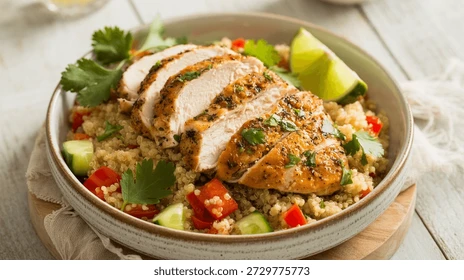

In [15]:
display(image)

## Creating a Multimodal Message

Qwen2-VL accepts a conversation containing:

- an image
- a text question

Example:

Image + "What food is shown?"
          ↓
       Qwen2-VL
          ↓
      Text answer

In [16]:
question = "What food is shown in this image?"

print("Question:", question)

Question: What food is shown in this image?


In [17]:
messages = [
    {
        "role": "user",
        "content": [
            {
                "type": "image",
                "image": image
            },
            {
                "type": "text",
                "text": question
            }
        ]
    }
]

print("Multimodal message created.")
print(messages[0]["role"])
print(messages[0]["content"][1]["text"])

Multimodal message created.
user
What food is shown in this image?


## Preparing the Qwen2-VL Input

The message currently contains human-readable information:

Image + Question

The processor converts this into tensors that Qwen2-VL can understand.

Flow:

Image + Question
       ↓
    Processor
       ↓
Model-ready inputs

In [18]:
text = processor.apply_chat_template(
    messages,
    tokenize=False,
    add_generation_prompt=True
)

print("Chat template created:")
print(text)

Chat template created:
<|im_start|>system
You are a helpful assistant.<|im_end|>
<|im_start|>user
<|vision_start|><|image_pad|><|vision_end|>What food is shown in this image?<|im_end|>
<|im_start|>assistant



In [19]:
print("Input text prepared successfully.")
print("Input type:", type(text))
print("Input length:", len(text))

Input text prepared successfully.
Input type: <class 'str'>
Input length: 184


In [20]:
inputs = processor(
    text=[text],
    images=[image],
    padding=True,
    return_tensors="pt"
)

print("Qwen2-VL inputs prepared successfully!")
print("Input keys:", inputs.keys())

Qwen2-VL inputs prepared successfully!
Input keys: dict_keys(['input_ids', 'attention_mask', 'pixel_values', 'image_grid_thw'])


## First Qwen2-VL Inference

We now send the prepared image and question
to the Qwen2-VL model.

Image + Question
       ↓
   Qwen2-VL
       ↓
Generated response

In [21]:
inputs = {key: value.to(device) for key, value in inputs.items()}

print("Inputs moved to:", device)

Inputs moved to: cpu


In [22]:
print("Generating Qwen2-VL response...")
print("This may take some time on CPU.")

with torch.no_grad():
    generated_ids = model.generate(
        **inputs,
        max_new_tokens=100
    )

print("Generation completed!")

Generating Qwen2-VL response...
This may take some time on CPU.
Generation completed!


In [24]:
# Remove the original input tokens.
# Keep only the tokens generated by Qwen2-VL.

input_token_length = inputs["input_ids"].shape[1]

generated_answer_ids = generated_ids[:, input_token_length:]

generated_text = processor.batch_decode(
    generated_answer_ids,
    skip_special_tokens=True
)[0]

print("Qwen2-VL response:")
print(generated_text)

Qwen2-VL response:
The image shows a dish that includes sliced chicken breast, quinoa, diced tomatoes, cucumber, and fresh cilantro. The dish is garnished with lime wedges and cilantro leaves.


## Standardizing Qwen2-VL Evidence

Different AI models produce different output formats.

We convert their outputs into a common evidence structure.

Qwen2-VL
    ↓
Raw visual description
    ↓
Structured evidence

This allows the future fusion engine to combine
Qwen2-VL, Florence-2, OCR, and FoodOn evidence.

In [26]:
qwen_evidence = {
    "source": "qwen2-vl",
    "model": MODEL_NAME,
    "task": "visual_food_description",
    "observations": [
        "sliced chicken breast",
        "quinoa",
        "diced tomatoes",
        "cucumber",
        "fresh cilantro",
        "lime wedges"
    ],
    "raw_output": generated_text
}

print(qwen_evidence)

{'source': 'qwen2-vl', 'model': 'Qwen/Qwen2-VL-2B-Instruct', 'task': 'visual_food_description', 'observations': ['sliced chicken breast', 'quinoa', 'diced tomatoes', 'cucumber', 'fresh cilantro', 'lime wedges'], 'raw_output': 'The image shows a dish that includes sliced chicken breast, quinoa, diced tomatoes, cucumber, and fresh cilantro. The dish is garnished with lime wedges and cilantro leaves.'}


In [27]:
print("Source:", qwen_evidence["source"])
print("Model:", qwen_evidence["model"])
print("Observations:")

for observation in qwen_evidence["observations"]:
    print("-", observation)

Source: qwen2-vl
Model: Qwen/Qwen2-VL-2B-Instruct
Observations:
- sliced chicken breast
- quinoa
- diced tomatoes
- cucumber
- fresh cilantro
- lime wedges


## Combining Vision Evidence

Florence-2 and Qwen2-VL were tested separately.

Their evidence is now represented in a common structure so that
we can compare the two independent vision sources.

In [30]:
florence_evidence = {
    "source": "florence-2",
    "model": "microsoft/Florence-2-base",
    "task": "<DENSE_REGION_CAPTION>",
    "observations": [
        "grilled chicken with couscous and vegetables",
        "grilled pork tenderloin with quinoa and vegetables",
        "sliced lime on plate with vegetables",
        "tomato",
        "tomato",
        "cucumber",
        "cucumber",
        "cucumber",
        "tomato",
        "tomato",
        "tomato",
        "tomato",
        "carrot"
    ]
}

print("Florence-2 evidence created.")

Florence-2 evidence created.


In [31]:
vision_evidence = {
    "florence_2": florence_evidence,
    "qwen2_vl": qwen_evidence
}

print("Vision evidence sources:")

for source in vision_evidence:
    print("-", source)

Vision evidence sources:
- florence_2
- qwen2_vl


## Comparing Vision Evidence

Two independent vision models can produce overlapping
or conflicting observations.

Agreement:
    Multiple models support similar evidence.

Conflict:
    Models provide incompatible observations.

This comparison is an early step toward the
Adaptive Evidence Fusion Engine.

In [32]:
florence_observations = vision_evidence["florence_2"]["observations"]
qwen_observations = vision_evidence["qwen2_vl"]["observations"]

print("Florence-2 observations:", len(florence_observations))
print("Qwen2-VL observations:", len(qwen_observations))

Florence-2 observations: 13
Qwen2-VL observations: 6


In [33]:
def normalize_observation(text):
    text = text.lower()
    text = text.replace(",", "")
    return text.strip()


florence_clean = [
    normalize_observation(x)
    for x in florence_observations
]

qwen_clean = [
    normalize_observation(x)
    for x in qwen_observations
]

print("Observation text normalized.")

Observation text normalized.


In [34]:
florence_set = set(florence_clean)
qwen_set = set(qwen_clean)

agreement = florence_set.intersection(qwen_set)

print("Potential exact agreements:")

for item in sorted(agreement):
    print("-", item)

Potential exact agreements:
- cucumber


In [35]:
florence_only = florence_set - qwen_set
qwen_only = qwen_set - florence_set

print("Florence-2 only:")
for item in sorted(florence_only):
    print("-", item)

print("\nQwen2-VL only:")
for item in sorted(qwen_only):
    print("-", item)

Florence-2 only:
- carrot
- grilled chicken with couscous and vegetables
- grilled pork tenderloin with quinoa and vegetables
- sliced lime on plate with vegetables
- tomato

Qwen2-VL only:
- diced tomatoes
- fresh cilantro
- lime wedges
- quinoa
- sliced chicken breast


## Evidence Concept Alignment

Different vision models may describe the same object using different words.

We preserve the original observation but map it to a common concept.

Example:

"sliced chicken breast" → "chicken"
"diced tomatoes" → "tomato"
"lime wedges" → "lime"

This is a simple baseline for evidence comparison.

In [36]:
concept_mapping = {
    "grilled chicken with couscous and vegetables": "chicken",
    "sliced chicken breast": "chicken",
    "grilled pork tenderloin with quinoa and vegetables": "pork",
    "tomato": "tomato",
    "diced tomatoes": "tomato",
    "cucumber": "cucumber",
    "sliced lime on plate with vegetables": "lime",
    "lime wedges": "lime",
    "carrot": "carrot",
    "fresh cilantro": "cilantro",
    "quinoa": "quinoa"
}

print("Concept mapping created.")
print("Mappings:", len(concept_mapping))

Concept mapping created.
Mappings: 11


In [37]:
def align_to_concept(observation):
    return concept_mapping.get(
        observation,
        observation
    )

In [38]:
florence_aligned = [
    align_to_concept(observation)
    for observation in florence_clean
]

print("Florence-2 aligned concepts:")

for concept in sorted(set(florence_aligned)):
    print("-", concept)

Florence-2 aligned concepts:
- carrot
- chicken
- cucumber
- lime
- pork
- tomato


In [39]:
qwen_aligned = [
    align_to_concept(observation)
    for observation in qwen_clean
]

print("Qwen2-VL aligned concepts:")

for concept in sorted(set(qwen_aligned)):
    print("-", concept)

Qwen2-VL aligned concepts:
- chicken
- cilantro
- cucumber
- lime
- quinoa
- tomato


In [40]:
florence_concepts = set(florence_aligned)
qwen_concepts = set(qwen_aligned)

concept_agreement = florence_concepts.intersection(qwen_concepts)

print("Semantic concept agreements:")

for concept in sorted(concept_agreement):
    print("-", concept)

Semantic concept agreements:
- chicken
- cucumber
- lime
- tomato


In [41]:
florence_concept_only = florence_concepts - qwen_concepts
qwen_concept_only = qwen_concepts - florence_concepts

print("Florence-2 unique concepts:")

for concept in sorted(florence_concept_only):
    print("-", concept)

print("\nQwen2-VL unique concepts:")

for concept in sorted(qwen_concept_only):
    print("-", concept)

Florence-2 unique concepts:
- carrot
- pork

Qwen2-VL unique concepts:
- cilantro
- quinoa


## Qwen2-VL Text Reading Experiment

Qwen2-VL can inspect an image and answer questions about visible text.

We will test whether it can identify text in the image.

This is not a replacement for PaddleOCR.
It gives us an additional vision-language evidence source.

In [42]:
question = "Read all visible text in this image. If there is no relevant text, say 'No readable text'."

messages = [
    {
        "role": "user",
        "content": [
            {
                "type": "image",
                "image": image
            },
            {
                "type": "text",
                "text": question
            }
        ]
    }
]

print("Qwen2-VL OCR-style question created.")
print(question)

Qwen2-VL OCR-style question created.
Read all visible text in this image. If there is no relevant text, say 'No readable text'.


In [43]:
text = processor.apply_chat_template(
    messages,
    tokenize=False,
    add_generation_prompt=True
)

inputs = processor(
    text=[text],
    images=[image],
    padding=True,
    return_tensors="pt"
)

print("Qwen2-VL OCR input prepared.")
print(inputs.keys())

Qwen2-VL OCR input prepared.
dict_keys(['input_ids', 'attention_mask', 'pixel_values', 'image_grid_thw'])


In [44]:
generated_ids = model.generate(
    **inputs,
    max_new_tokens=100
)

print("Generation completed.")

Generation completed.


In [46]:
output = processor.batch_decode(
    generated_ids,
    skip_special_tokens=True
)[0]

print("Qwen2-VL OCR-style output:")
print(output)

Qwen2-VL OCR-style output:
system
You are a helpful assistant.
user
Read all visible text in this image. If there is no relevant text, say 'No readable text'.
assistant
(201,101),(301,350)


In [47]:
generated_only = generated_ids[:, inputs["input_ids"].shape[1]:]

qwen_ocr_output = processor.batch_decode(
    generated_only,
    skip_special_tokens=True
)[0].strip()

print("Qwen2-VL generated answer:")
print(qwen_ocr_output)

Qwen2-VL generated answer:
(201,101),(301,350)


In [48]:
qwen_ocr_evidence = {
    "source": "qwen2-vl",
    "task": "text_reading",
    "text": qwen_ocr_output
}

print(qwen_ocr_evidence)

{'source': 'qwen2-vl', 'task': 'text_reading', 'text': '(201,101),(301,350)'}
